# Notebook 01.13: MobileNetV2 — Full Fine-Tune + Full TTA

Same backbone as `01.12`, but **all layers unfrozen** from the start (no staged freeze/unfreeze). Mirrors the Auste-style recipe that worked well for ResNet18 in 04.x, but applied to MobileNetV2.

- **All params trainable** — single `Adam(lr=5e-5)` over `model.parameters()`.
- Smaller LR than the ResNet recipe (5e-5 vs 1e-4) because MobileNetV2's bottleneck layers are more fragile under aggressive fine-tuning.
- **10 epochs**, save best-val-AUROC checkpoint.
- IMG_SIZE=512, batch 8, augmentation on training set.
- **Multi-scale + hflip TTA** at inference.

### Why a separate notebook
- `01.12` uses the staged approach (frozen → partial unfreeze → + aug) which is the "safe middle path". Good for unknown territory.
- `01.13` commits to full fine-tune. Higher ceiling if it works, small risk of wrecking pretrained features at 5e-5.
- Pairing the winner of this vs 04.2/04.3 gives an ensemble of two different architectures, which should diversify errors and improve the final score.

---
## Step 1: Imports

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2
from tqdm.auto import tqdm

print("Imports OK")

Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and Device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Step 3: Configuration

Single-stage recipe — all layers trainable, `Adam(lr=5e-5)`, 10 epochs. `IMG_SIZE=512` keeps the heart-width signal sharp.

In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 0
VAL_FRAC = 0.2
EPOCHS = 10
LR = 5e-5               # gentle LR for full fine-tune of MobileNetV2

# Multi-scale TTA: 6 views total (3 scales × 2 flips)
TTA_SCALES = [IMG_SIZE, IMG_SIZE + 64, IMG_SIZE + 128]
TTA_HFLIP = True

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"EPOCHS    : {EPOCHS}")
print(f"LR        : {LR}")
print(f"TTA scales: {TTA_SCALES}  (hflip={TTA_HFLIP})")

IMG_SIZE  : 512
BATCH_SIZE: 8
EPOCHS    : 10
LR        : 5e-05
TTA scales: [512, 576, 640]  (hflip=True)


## Step 4: Load labels and inspect class balance

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df.head())
print("\nFinding counts:")
print(df["finding"].value_counts())
print(f"\nPositive rate: {df['label'].mean():.3f}")
print(f"Total         : {len(df)}")

       image_file  age sex       finding  label
0  IMG_000838.png   65   F  Cardiomegaly      1
1  IMG_000239.png   76   F  Cardiomegaly      1
2  IMG_000217.png   61   M    No Finding      0
3  IMG_001193.png   52   F    No Finding      0
4  IMG_001097.png   35   F    No Finding      0

Finding counts:
finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64

Positive rate: 0.456
Total         : 1578


## Step 5: Dataset class

Handles the mixed grayscale (`L`) and `RGBA` modes in the PNGs — MobileNetV2 expects 3-channel RGB.

In [5]:
class CardiomegalyDataset(Dataset):
    """Reads chest X-rays from a folder of PNGs + a DataFrame with labels."""

    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        # grayscale → repeat 3 channels; RGBA → drop alpha; RGB → pass
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)

## Step 6: Stratified train / validation split

80/20, stratified on the label to preserve the Cardiomegaly / No Finding ratio in both halves.

In [6]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["label"], random_state=SEED
)
print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")

Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


## Step 7: Transforms

Train set uses augmentation (hflip + small rotation + mild color jitter). Val/test use clean resize only.

In [7]:
def build_transform(img_size, augment=False):
    ops = []
    if img_size is not None:
        ops.append(T.Resize((img_size, img_size)))
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

# Training uses augmentation; val/test use clean resize only.
train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 158
Val   batches: 40


## Step 8: Peek at a batch

Batch shape: torch.Size([8, 3, 512, 512])  dtype: torch.float32
Labels     : [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]


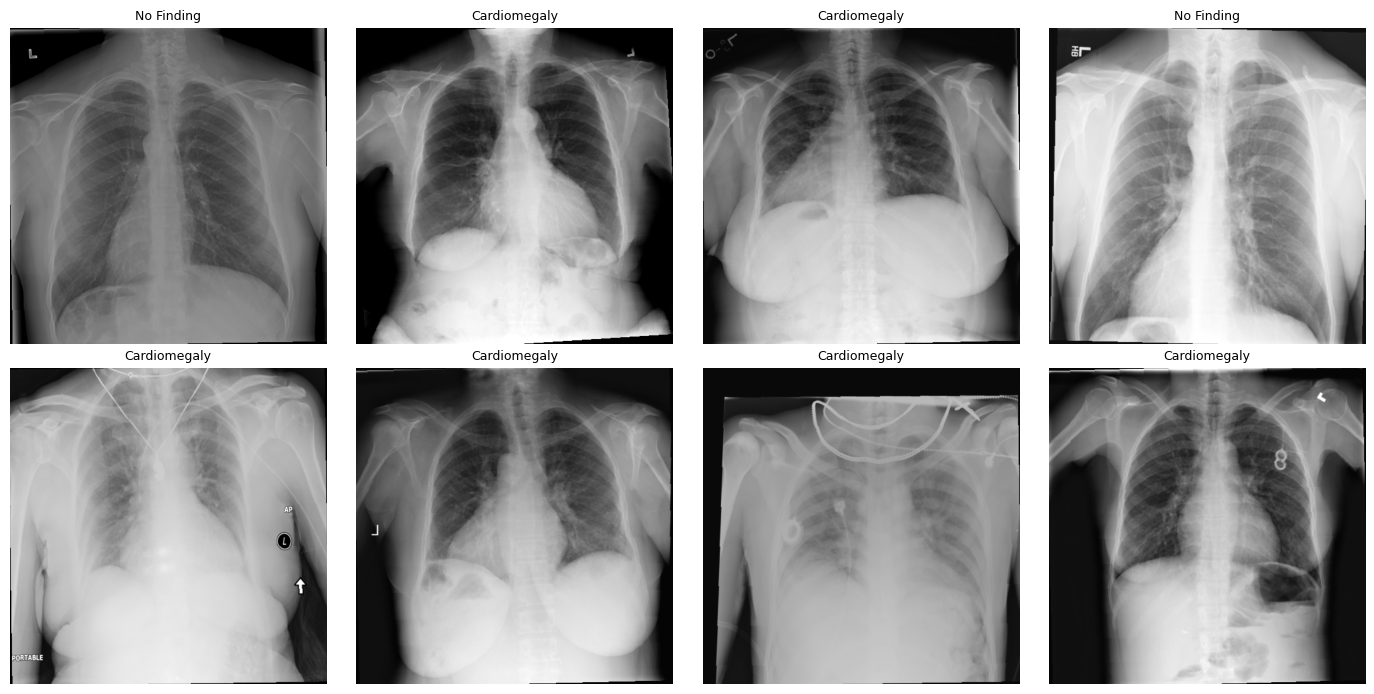

In [8]:
def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}  dtype: {imgs.dtype}")
print(f"Labels     : {labels.tolist()}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, lbl in zip(axes.flat, imgs, labels):
    ax.imshow(denorm(img).permute(1, 2, 0).numpy())
    ax.set_title("Cardiomegaly" if lbl.item() else "No Finding", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Metrics helpers

The datathon scores on **AUROC + Sensitivity + Specificity**, so we compute all three every epoch. Threshold for sens/spec starts at 0.5 and we pick a better one (Youden's J) after training.

In [9]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold(y_true, y_prob):
    """Threshold that maximises Youden's J (sens + spec - 1)."""
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

## Train / Eval loops

In [10]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, epochs, device, tag="model"):
    criterion = nn.BCEWithLogitsLoss()
    best = {"auroc": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        dt = time.time() - t0
        score = datathon_score(val["auroc"], val["sens"], val["spec"])
        history.append({"epoch": epoch, "loss": tr_loss, **{k: val[k] for k in ("auroc", "sens", "spec")}, "score": score})
        star = ""
        if val["auroc"] > best["auroc"]:
            best = {"auroc": val["auroc"], "state": copy.deepcopy(model.state_dict()), "epoch": epoch}
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {val['sens']:.3f}  spec {val['spec']:.3f}  "
            f"score {score:.4f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, history, best

---
## Full TTA helper (multi-scale + hflip)

Runs the model at multiple image sizes and optionally their horizontal flips, then averages sigmoid probabilities. Used for validation-set threshold selection *and* test-set submission so the threshold matches the inference regime.

In [11]:
@torch.no_grad()
def predict_probs_tta(model, loader, device, tta_scales=None, tta_hflip=False, return_labels=False):
    """Average sigmoid probabilities across multi-scale + hflip views."""
    model.eval()
    all_probs = []
    all_labels = []
    for batch in loader:
        imgs = batch[0].to(device)
        scales = tta_scales if tta_scales else [imgs.shape[-1]]
        prob_sum = torch.zeros(imgs.size(0), device=device)
        n_views = 0
        for s in scales:
            view = imgs if s == imgs.shape[-1] else F.interpolate(imgs, size=(s, s), mode="bilinear", align_corners=False)
            prob_sum = prob_sum + torch.sigmoid(model(view).squeeze(1))
            n_views += 1
            if tta_hflip:
                prob_sum = prob_sum + torch.sigmoid(model(torch.flip(view, dims=[3])).squeeze(1))
                n_views += 1
        all_probs.append((prob_sum / n_views).cpu().numpy())
        if return_labels:
            all_labels.append(batch[1].numpy())
    probs = np.concatenate(all_probs)
    if return_labels:
        return probs, np.concatenate(all_labels)
    return probs


def evaluate_tta(model, loader, device, tta_scales=None, tta_hflip=False):
    """evaluate() but with TTA. Returns same dict shape."""
    p, y = predict_probs_tta(model, loader, device, tta_scales=tta_scales, tta_hflip=tta_hflip, return_labels=True)
    auroc = roc_auc_score(y, p)
    sens, spec = sens_spec(y, p, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": y, "p": p}

---
## Full fine-tune: all layers trainable

Replace the classifier head with `Dropout(0.3) → Linear(1280, 1)`, leave every other parameter trainable. Single `Adam(lr=5e-5)` over `model.parameters()`. Augmentation is already baked into the training loader.

In [12]:
def build_full_finetune():
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    # All params remain trainable (no freezing).
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, 1))
    return model

model = build_full_finetune().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")

optimizer = optim.Adam(model.parameters(), lr=LR)
model, history, best = train(
    model, train_loader, val_loader, optimizer, epochs=EPOCHS, device=device, tag="mobilenet_fullft"
)

Trainable: 2,225,153 / 2,225,153 (100.00%)


[mobilenet_fullft] ep 01/10  loss 0.5984  AUROC 0.8615  sens 0.493  spec 0.948  score 0.7909  (69.7s) ★


[mobilenet_fullft] ep 02/10  loss 0.4814  AUROC 0.9117  sens 0.792  spec 0.843  score 0.8645  (61.4s) ★


[mobilenet_fullft] ep 03/10  loss 0.4159  AUROC 0.9310  sens 0.931  spec 0.756  score 0.8871  (61.2s) ★


[mobilenet_fullft] ep 04/10  loss 0.3776  AUROC 0.9123  sens 0.812  spec 0.808  score 0.8613  (61.1s)


...

[mobilenet_fullft] ep 06/10  loss 0.3037  AUROC 0.9499  sens 0.847  spec 0.913  score 0.9149  (61.1s) ★


[mobilenet_fullft] ep 07/10  loss 0.2544  AUROC 0.9437  sens 0.910  spec 0.802  score 0.8999  (60.7s)


[mobilenet_fullft] ep 08/10  loss 0.2221  AUROC 0.9239  sens 0.868  spec 0.785  score 0.8752  (60.9s)


[mobilenet_fullft] ep 09/10  loss 0.1895  AUROC 0.9390  sens 0.806  spec 0.936  score 0.9049  (60.7s)


[mobilenet_fullft] ep 10/10  loss 0.2339  AUROC 0.9308  sens 0.882  spec 0.826  score 0.8923  (64.6s)


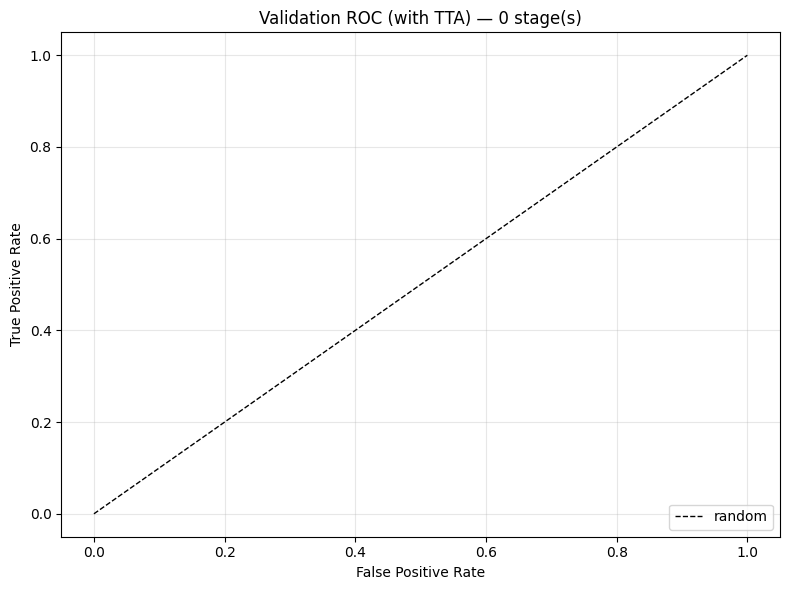

In [13]:
# Only plot whichever stages have been trained so far.
available = [(tag, name) for tag, name in [("frozen", "model_frozen"), ("finetune", "model_ft"), ("aug", "model_aug")] if name in globals()]

fig, ax = plt.subplots(figsize=(8, 6))
for tag, name in available:
    m = globals()[name]
    val = evaluate_tta(m, val_loader, device, tta_scales=TTA_SCALES, tta_hflip=TTA_HFLIP)
    fpr, tpr, _ = roc_curve(val["y"], val["p"])
    ax.plot(fpr, tpr, lw=2, label=f"{tag}  AUROC={val['auroc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Validation ROC (with TTA) — {len(available)} stage(s)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

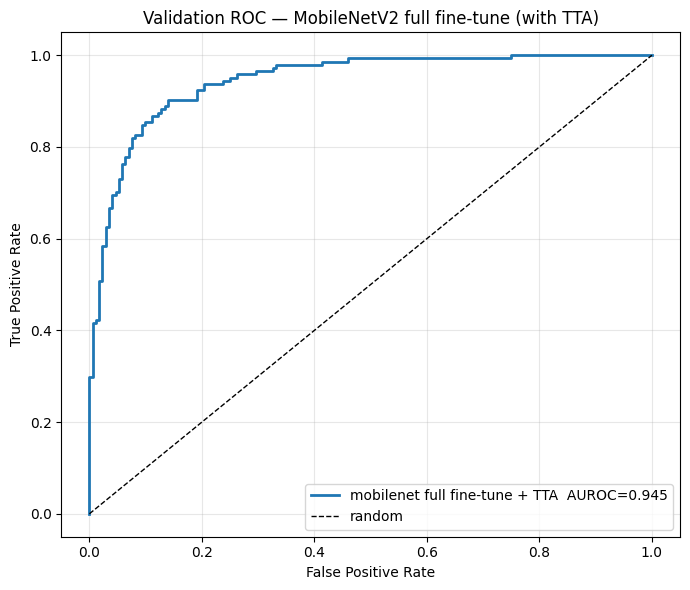

In [14]:
val = evaluate_tta(model, val_loader, device, tta_scales=TTA_SCALES, tta_hflip=TTA_HFLIP)
fpr, tpr, _ = roc_curve(val["y"], val["p"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2, label=f"mobilenet full fine-tune + TTA  AUROC={val['auroc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC — MobileNetV2 full fine-tune (with TTA)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Threshold tuning

Grid-search threshold 0.1 → 0.9 in 0.05 steps on the TTA-averaged validation probabilities. Pick the one that maximizes the datathon score directly.

In [15]:
# Grid-search threshold on TTA-averaged val probs to maximize datathon score.
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    s, sp = sens_spec(val["y"], val["p"], threshold=t)
    rows.append({"threshold": t, "auc": val["auroc"], "sens": s, "spec": sp,
                 "score": datathon_score(val["auroc"], s, sp)})
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

best_row = results_df.loc[results_df["score"].idxmax()]
best_thr = float(best_row["threshold"])
best_score = float(best_row["score"])
print(f"\nBest threshold: {best_thr:.2f}  score: {best_score:.4f}")

 threshold      auc     sens     spec    score
      0.10 0.945252 0.993056 0.337209 0.805192
      0.15 0.945252 0.993056 0.406977 0.822634
      0.20 0.945252 0.993056 0.494186 0.844436
      0.25 0.945252 0.986111 0.558140 0.858689
      0.30 0.945252 0.979167 0.610465 0.870034
      0.35 0.945252 0.979167 0.668605 0.884569
      0.40 0.945252 0.972222 0.674419 0.884286
      0.45 0.945252 0.965278 0.703488 0.889818
      0.50 0.945252 0.951389 0.744186 0.896520
      0.55 0.945252 0.937500 0.790698 0.904675
      0.60 0.945252 0.902778 0.813953 0.901809
      0.65 0.945252 0.881944 0.872093 0.911135
      0.70 0.945252 0.861111 0.889535 0.910287
      0.75 0.945252 0.798611 0.924419 0.903383
      0.80 0.945252 0.729167 0.947674 0.891836
      0.85 0.945252 0.659722 0.965116 0.878836
      0.90 0.945252 0.583333 0.970930 0.861192

Best threshold: 0.65  score: 0.9111


In [16]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

best_model.eval()
all_probs, all_names = [], []
with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc="test inference"):
        imgs = imgs.to(device)
        logits = best_model(imgs).squeeze(1)
        # Test-time augmentation: average with horizontal flip
        logits_flip = best_model(torch.flip(imgs, dims=[3])).squeeze(1)
        probs = (torch.sigmoid(logits) + torch.sigmoid(logits_flip)) / 2
        all_probs.extend(probs.cpu().numpy().tolist())
        all_names.extend(names)

sub = pd.DataFrame({
    "image_file": all_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_{best_name}_{stamp}.csv"
sub.to_csv(out_path, index=False)
print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")

Test images: 176


NameError: name 'best_model' is not defined

In [ ]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Full multi-scale + hflip TTA for submission
test_probs = predict_probs_tta(model, test_loader, device, tta_scales=TTA_SCALES, tta_hflip=TTA_HFLIP)
all_names = [name for _, name in test_ds]

sub = pd.DataFrame({"image_file": all_names, "prob": test_probs.tolist()})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_mobilenet_fullft_fullTTA_{stamp}.csv"
sub.to_csv(out_path, index=False)
print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")